## Implementation of perceptron learning model on Iris dataset.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [5]:
class Perceptron:

    def __init__(self, learning_rate=0.01, n_epochs=50, random_state=1):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.random_state = random_state

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        n_samples, n_features = X.shape

        # small random init for weights, bias starts at 0
        self.w_ = rng.normal(loc=0.0, scale=0.01, size=n_features)
        self.b_ = 0.0

        self.errors_per_epoch_ = []

        for epoch in range(self.n_epochs):
            errors = 0
            for xi, target in zip(X, y):
                net_input = np.dot(xi, self.w_) + self.b_
                y_pred = 1 if net_input >= 0 else -1

                # perceptron update rule: only fires on misclassification
                update = self.lr * (target - y_pred) / 2  # (target-y_pred)/2 in {-1,0,1}
                if update != 0:
                    self.w_ += update * xi
                    self.b_ += update
                    errors += 1
            self.errors_per_epoch_.append(errors)

            # early stop once the data is perfectly separated
            if errors == 0:
                print(f"Converged after {epoch + 1} epochs.")
                break

        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return np.where(self.net_input(X) >= 0, 1, -1)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

### Load Iris dataset

In [6]:
iris = load_iris()
X_full = iris.data
y_full = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

In [7]:
feat_idx = [2, 3]  # petal length, petal width
mask = y_full != 2  # keep only Setosa & Versicolor

In [8]:
X = X_full[mask][:, feat_idx]
y_raw = y_full[mask]
y = np.where(y_raw == 0, -1, 1)  # Setosa -> -1, Versicolor -> +1

In [9]:

# 3. Train/test split (implemented manually, no train_test_split)

rng = np.random.RandomState(42)
indices = rng.permutation(len(X))
split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Standardize features (helps convergence); computed from train set only
mu, sigma = X_train.mean(axis=0), X_train.std(axis=0)
X_train_std = (X_train - mu) / sigma
X_test_std = (X_test - mu) / sigma

In [10]:
# 4. Train the perceptron

model = Perceptron(learning_rate=0.01, n_epochs=50, random_state=1)
model.fit(X_train_std, y_train)

train_acc = model.accuracy(X_train_std, y_train)
test_acc = model.accuracy(X_test_std, y_test)

print(f"Final weights: {model.w_}, bias: {model.b_:.4f}")
print(f"Train accuracy: {train_acc * 100:.2f}%")
print(f"Test accuracy:  {test_acc * 100:.2f}%")

Converged after 2 epochs.
Final weights: [1.77885711e-02 1.24200534e-05], bias: 0.0100
Train accuracy: 100.00%
Test accuracy:  100.00%


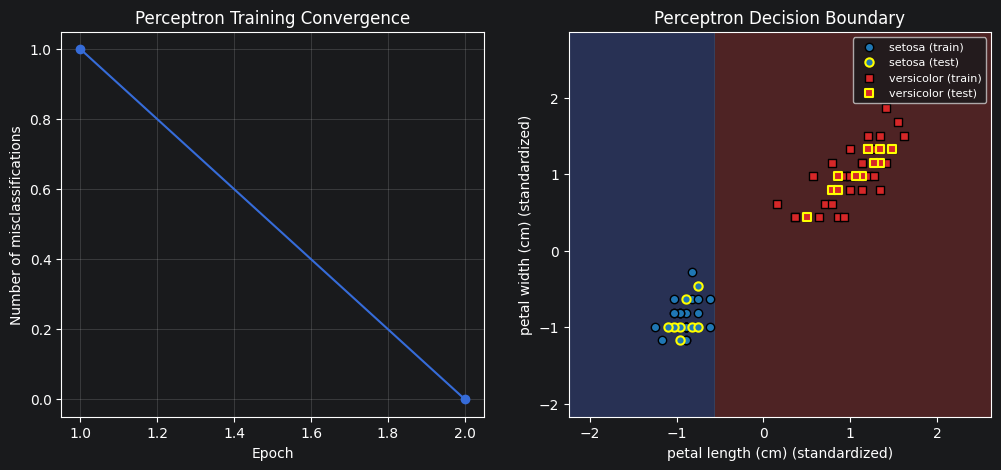

In [11]:
# 5. Plots: (a) training errors per epoch, (b) decision boundary

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Errors per epoch
axes[0].plot(range(1, len(model.errors_per_epoch_) + 1),
             model.errors_per_epoch_, marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Number of misclassifications')
axes[0].set_title('Perceptron Training Convergence')
axes[0].grid(alpha=0.3)

# (b) Decision boundary (on standardized features)
x1_min, x1_max = X_train_std[:, 0].min() - 1, X_train_std[:, 0].max() + 1
x2_min, x2_max = X_train_std[:, 1].min() - 1, X_train_std[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                        np.linspace(x2_min, x2_max, 300))
grid = np.c_[xx1.ravel(), xx2.ravel()]
Z = model.predict(grid).reshape(xx1.shape)

axes[1].contourf(xx1, xx2, Z, alpha=0.3, cmap='coolwarm')
for cls, marker, color, label in [(-1, 'o', 'tab:blue', target_names[0]),
                                   (1, 's', 'tab:red', target_names[1])]:
    axes[1].scatter(X_train_std[y_train == cls, 0],
                     X_train_std[y_train == cls, 1],
                     marker=marker, color=color, edgecolor='k',
                     label=f'{label} (train)')
    axes[1].scatter(X_test_std[y_test == cls, 0],
                     X_test_std[y_test == cls, 1],
                     marker=marker, color=color, edgecolor='yellow',
                     linewidth=1.5, label=f'{label} (test)')

axes[1].set_xlabel(f'{feature_names[feat_idx[0]]} (standardized)')
axes[1].set_ylabel(f'{feature_names[feat_idx[1]]} (standardized)')
axes[1].set_title('Perceptron Decision Boundary')
axes[1].legend(loc='best', fontsize=8)